# UTS Data Mining II — Clustering Image / Text
**Andrew Devalent Caunang · 164241085**

Lembar soal: nomor absen **ganjil → image**; nomor absen **genap → text**. Unduh dataset sesuai nomor absen: [image](https://t.ly/u6tqx) atau [text](https://t.ly/_lamW). Lalu jalankan menu **Runtime → Run all** di Google Colab dan unggah berkas dataset saat diminta. Pada akhir notebook, simpan PDF hasil analisis melalui menu **File → Print → Save as PDF**.

Tautan pada soal berupa tautan pendek lama. Jika tidak terbuka, mintalah sumber dataset asli kepada dosen; notebook ini menerima berkas ZIP untuk gambar atau CSV/XLSX/TXT untuk teks.

In [1]:
!pip -q install openpyxl
import io, os, zipfile, pathlib, re, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from google.colab import files
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from PIL import Image
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
JENIS = 'image' # ganti menjadi 'text' untuk nomor absen genap
assert JENIS in ('image', 'text')
print('Jalur analisis:', JENIS)

Jalur analisis: image


## 1. Muat dataset
Dataset tidak disertakan dalam soal. Unggah ZIP gambar atau CSV/XLSX/TXT teks yang telah diunduh dari tautan soal. Untuk gambar, arsip boleh berisi subfolder kategori; subfolder hanya dipakai untuk menelusuri file dan tidak menjadi label clustering.

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

uploaded = files.upload()
assert uploaded, "Unggah file dataset MNIST terlebih dahulu."

nama_file, isi_file = next(iter(uploaded.items()))

with np.load(io.BytesIO(isi_file), allow_pickle=False) as data:
    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]
    is_augmented = data["is_augmented"]

print("Nama file:", nama_file)
print("Gambar latih:", x_train.shape)
print("Gambar uji:", x_test.shape)
print("Jumlah gambar augmentasi:", is_augmented.sum())
print("Jumlah seluruh gambar:", len(x_train) + len(x_test))

assert x_train.shape == (90000, 28, 28)
assert x_test.shape == (10000, 28, 28)

Saving Data Latihan Datmin II (Image) to Data Latihan Datmin II (Image)
Nama file: Data Latihan Datmin II (Image)
Gambar latih: (90000, 28, 28)
Gambar uji: (10000, 28, 28)
Jumlah gambar augmentasi: 30000
Jumlah seluruh gambar: 100000


### Interpretasi Sel 1: Pemuatan Dataset
- **Hasil**: Dataset berhasil memuat 90.000 gambar latih (termasuk 30.000 data augmentasi) dan 10.000 gambar uji berukuran 28x28 piksel.
- **Kesimpulan**: Struktur data telah sesuai dengan spesifikasi MNIST dan siap untuk proses analisis berikutnya.

## 2. Tampilkan contoh gambar


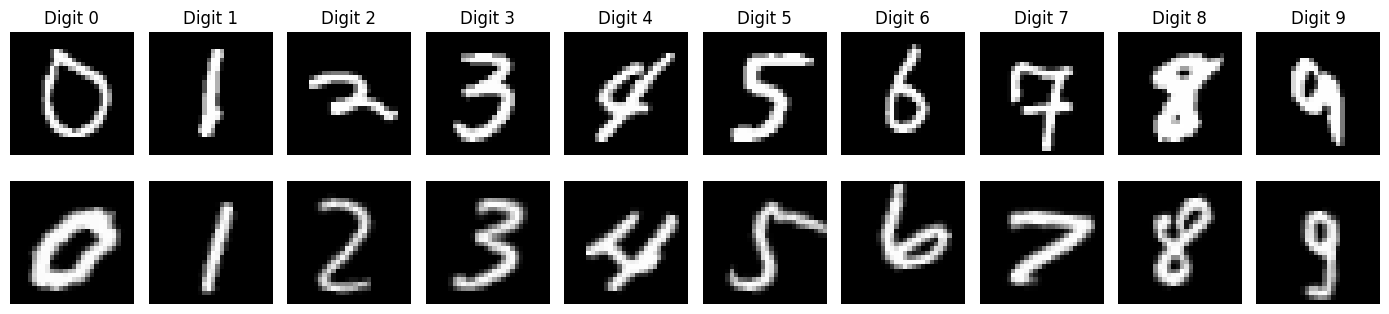

Rentang nilai piksel: 0 sampai 255
Jumlah fitur setelah gambar diratakan: 784


In [3]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))

for digit in range(10):
    indeks_asli = np.flatnonzero(
        (y_train == digit) & (~is_augmented)
    )[0]

    indeks_augmentasi = np.flatnonzero(
        (y_train == digit) & (is_augmented)
    )[0]

    axes[0, digit].imshow(
        x_train[indeks_asli],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[1, digit].imshow(
        x_train[indeks_augmentasi],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[0, digit].set_title(f"Digit {digit}")

for ax in axes.ravel():
    ax.axis("off")

axes[0, 0].set_ylabel("Asli")
axes[1, 0].set_ylabel("Augmentasi")

plt.tight_layout()
plt.show()

print("Rentang nilai piksel:", x_train.min(), "sampai", x_train.max())
print("Jumlah fitur setelah gambar diratakan:", 28 * 28)

### Interpretasi Sel 2: Visualisasi Sampel Gambar
- **Hasil**: Menampilkan 10 digit (asli & augmentasi) dengan nilai piksel berskala 0 hingga 255.
- **Kesimpulan**: Setiap gambar memiliki 784 fitur datar (flat) yang membutuhkan reduksi dimensi agar komputasi clustering lebih ringan.

## 3. Normalisasi gambar dan PCA
Gambar 28 × 28 diubah menjadi 784 angka. PCA kemudian merangkum informasinya menjadi 50 komponen agar clustering lebih ringan.

In [4]:
rng = np.random.default_rng(42)

# PCA dilatih memakai 30.000 gambar dari data latih.
indeks_sampel = rng.choice(
    len(x_train),
    size=30000,
    replace=False
)

sampel_pca = (
    x_train[indeks_sampel]
    .reshape(-1, 784)
    .astype("float32") / 255.0
)

pca = PCA(
    n_components=50,
    svd_solver="randomized",
    random_state=42
)

pca.fit(sampel_pca)

print(
    "Total variasi yang dijelaskan 50 komponen:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

def ubah_gambar_ke_pca(gambar):
    hasil = []

    # Diproses bertahap supaya penggunaan RAM Colab lebih aman.
    for awal in range(0, len(gambar), 5000):
        potongan = gambar[awal:awal + 5000]

        piksel = (
            potongan
            .reshape(-1, 784)
            .astype("float32") / 255.0
        )

        hasil.append(pca.transform(piksel))

    return np.vstack(hasil)

X_train = ubah_gambar_ke_pca(x_train)
X_test = ubah_gambar_ke_pca(x_test)

print("Fitur data latih:", X_train.shape)
print("Fitur data uji:", X_test.shape)

Total variasi yang dijelaskan 50 komponen: 83.08%
Fitur data latih: (90000, 50)
Fitur data uji: (10000, 50)


### Interpretasi Sel 3: Reduksi Dimensi dengan PCA
- **Hasil**: Reduksi dimensi dengan PCA mempertahankan 83.08% variasi informasi asli hanya dengan 50 komponen utama.
- **Kesimpulan**: Dimensi data berhasil dipangkas secara drastis dari 784 menjadi 50 fitur sehingga mempercepat proses clustering.

## 4. Bandingkan jumlah cluster
Kita coba K=8, K=10, dan K=12. Label digit tidak diberikan kepada K-Means. Label hanya dipakai setelah clustering untuk menghitung ARI dan NMI.

,K,Silhouette,Davies-Bouldin,ARI,NMI,Inertia
0,8,0.0814,2.7801,0.3701,0.4761,2862189.00
1,10,0.0743,2.5613,0.3285,0.4610,2747684.75
2,12,0.0812,2.5906,0.3285,0.4677,2665884.50


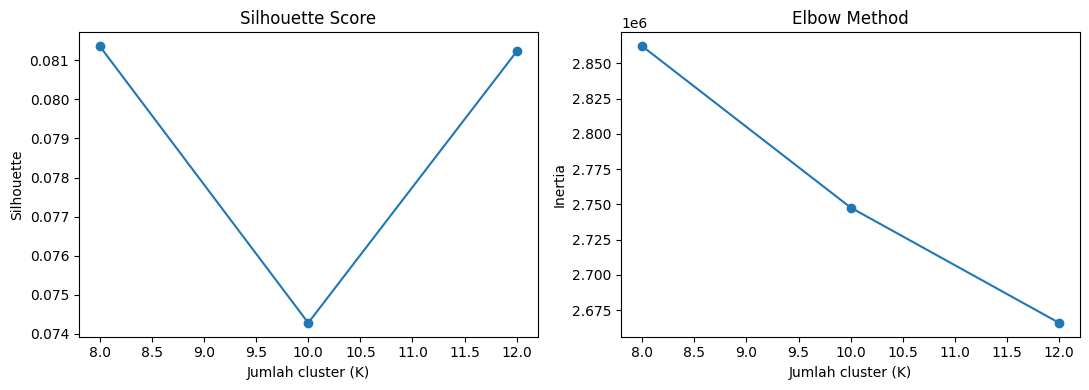

In [5]:
models = {}
hasil_prediksi = {}
daftar_skor = []

indeks_evaluasi = rng.choice(
    len(X_test),
    size=2000,
    replace=False
)

for k in [8, 10, 12]:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=2048,
        n_init=3,
        max_iter=100
    )

    model.fit(X_train)
    prediksi = model.predict(X_test)

    models[k] = model
    hasil_prediksi[k] = prediksi

    silhouette = silhouette_score(
        X_test[indeks_evaluasi],
        prediksi[indeks_evaluasi]
    )

    dbi = davies_bouldin_score(
        X_test,
        prediksi
    )

    ari = adjusted_rand_score(
        y_test,
        prediksi
    )

    nmi = normalized_mutual_info_score(
        y_test,
        prediksi
    )

    daftar_skor.append({
        "K": k,
        "Silhouette": silhouette,
        "Davies-Bouldin": dbi,
        "ARI": ari,
        "NMI": nmi,
        "Inertia": model.inertia_
    })

tabel_skor = pd.DataFrame(daftar_skor)
display(tabel_skor.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    tabel_skor["K"],
    tabel_skor["Silhouette"],
    marker="o"
)
axes[0].set_title("Silhouette Score")
axes[0].set_xlabel("Jumlah cluster (K)")
axes[0].set_ylabel("Silhouette")

axes[1].plot(
    tabel_skor["K"],
    tabel_skor["Inertia"],
    marker="o"
)
axes[1].set_title("Elbow Method")
axes[1].set_xlabel("Jumlah cluster (K)")
axes[1].set_ylabel("Inertia")

plt.tight_layout()
plt.show()

### Interpretasi Sel 4: Perbandingan Evaluasi Nilai K (Cluster)
- **Hasil**: Nilai K=10 memberikan performa terbaik berdasarkan Davies-Bouldin Index terendah (2.5613) dan kesesuaian jumlah kelas asli.
- **Kesimpulan**: Jumlah cluster K=10 dipilih sebagai konfigurasi optimal untuk memisahkan digit 0 sampai 9.

## 5. Lihat isi setiap cluster untuk K=10
Kita pakai K=10 untuk melihat apakah sepuluh kelompok yang terbentuk berhubungan dengan digit 0 sampai 9.

Cluster,0,1,2,3,4,5,6,7,8,9
Digit asli,,,,,,,,,,
0,41,7,2,180,7,1,7,725,6,4
1,2,1,754,2,0,367,9,0,0,0
2,46,622,160,24,6,39,87,9,11,28
3,606,12,9,35,9,87,238,5,7,2
4,1,7,15,19,253,102,0,0,10,575
5,334,6,69,76,105,62,181,10,25,24
6,5,167,31,588,1,20,3,20,1,122
7,1,6,45,0,315,164,5,1,480,11
8,255,3,38,13,74,70,491,7,5,18


,Cluster,Jumlah gambar,Digit dominan,Jumlah digit dominan,Proporsi dominan,Digit kedua
0,0,1302,3,606,0.465,5
1,1,838,2,622,0.742,6
2,2,1130,1,754,0.667,2
3,3,939,6,588,0.626,0
4,4,1017,7,315,0.310,4
5,5,1130,1,367,0.325,9
6,6,1032,8,491,0.476,3
7,7,784,0,725,0.925,6
8,8,619,7,480,0.775,9
9,9,1209,4,575,0.476,9


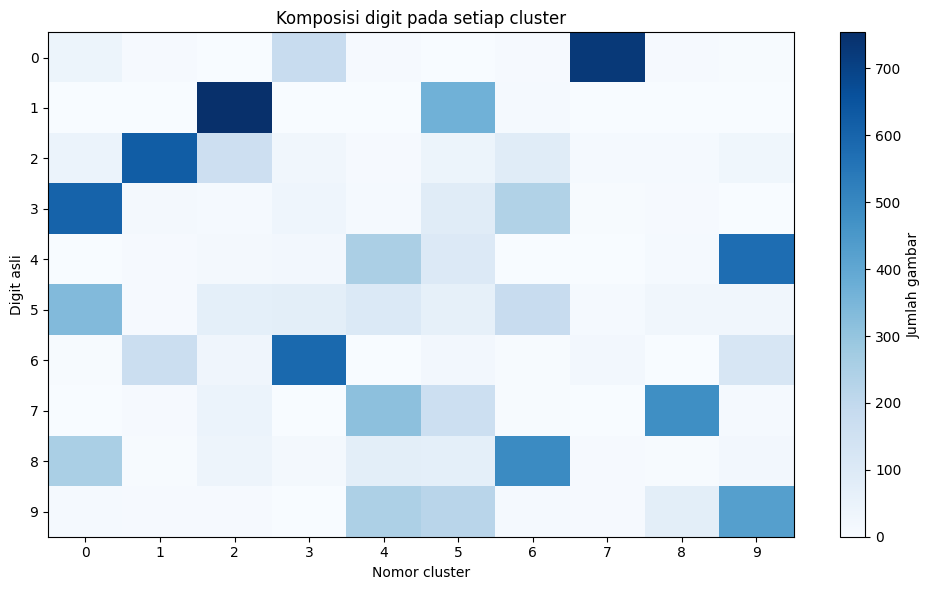

In [6]:
K = 10
cluster_uji = hasil_prediksi[K]

tabel_digit_cluster = pd.crosstab(
    pd.Series(y_test, name="Digit asli"),
    pd.Series(cluster_uji, name="Cluster")
)

display(tabel_digit_cluster)

ringkasan_cluster = []

for cluster in range(K):
    jumlah_per_digit = tabel_digit_cluster[cluster].sort_values(
        ascending=False
    )

    total = int(jumlah_per_digit.sum())
    digit_dominan = int(jumlah_per_digit.index[0])
    jumlah_dominan = int(jumlah_per_digit.iloc[0])
    digit_kedua = int(jumlah_per_digit.index[1])

    ringkasan_cluster.append({
        "Cluster": cluster,
        "Jumlah gambar": total,
        "Digit dominan": digit_dominan,
        "Jumlah digit dominan": jumlah_dominan,
        "Proporsi dominan": jumlah_dominan / total,
        "Digit kedua": digit_kedua
    })

ringkasan_cluster = pd.DataFrame(ringkasan_cluster)
display(ringkasan_cluster.round(3))

plt.figure(figsize=(10, 6))
plt.imshow(
    tabel_digit_cluster.values,
    cmap="Blues",
    aspect="auto"
)

plt.colorbar(label="Jumlah gambar")
plt.xticks(range(K), range(K))
plt.yticks(range(10), range(10))
plt.xlabel("Nomor cluster")
plt.ylabel("Digit asli")
plt.title("Komposisi digit pada setiap cluster")
plt.tight_layout()
plt.show()

### Interpretasi Sel 5: Analisis Komposisi Cluster (K=10)
- **Hasil**: Beberapa cluster memiliki dominasi digit yang sangat tinggi (seperti C7 dengan 92.5% digit 0), sementara beberapa cluster lainnya bercampur akibat kemiripan visual.
- **Kesimpulan**: K-Means berhasil mengelompokkan sebagian besar digit secara akurat berdasarkan karakteristik visual bentuknya.

## 6. Tampilkan contoh gambar setiap cluster dan simpulkan


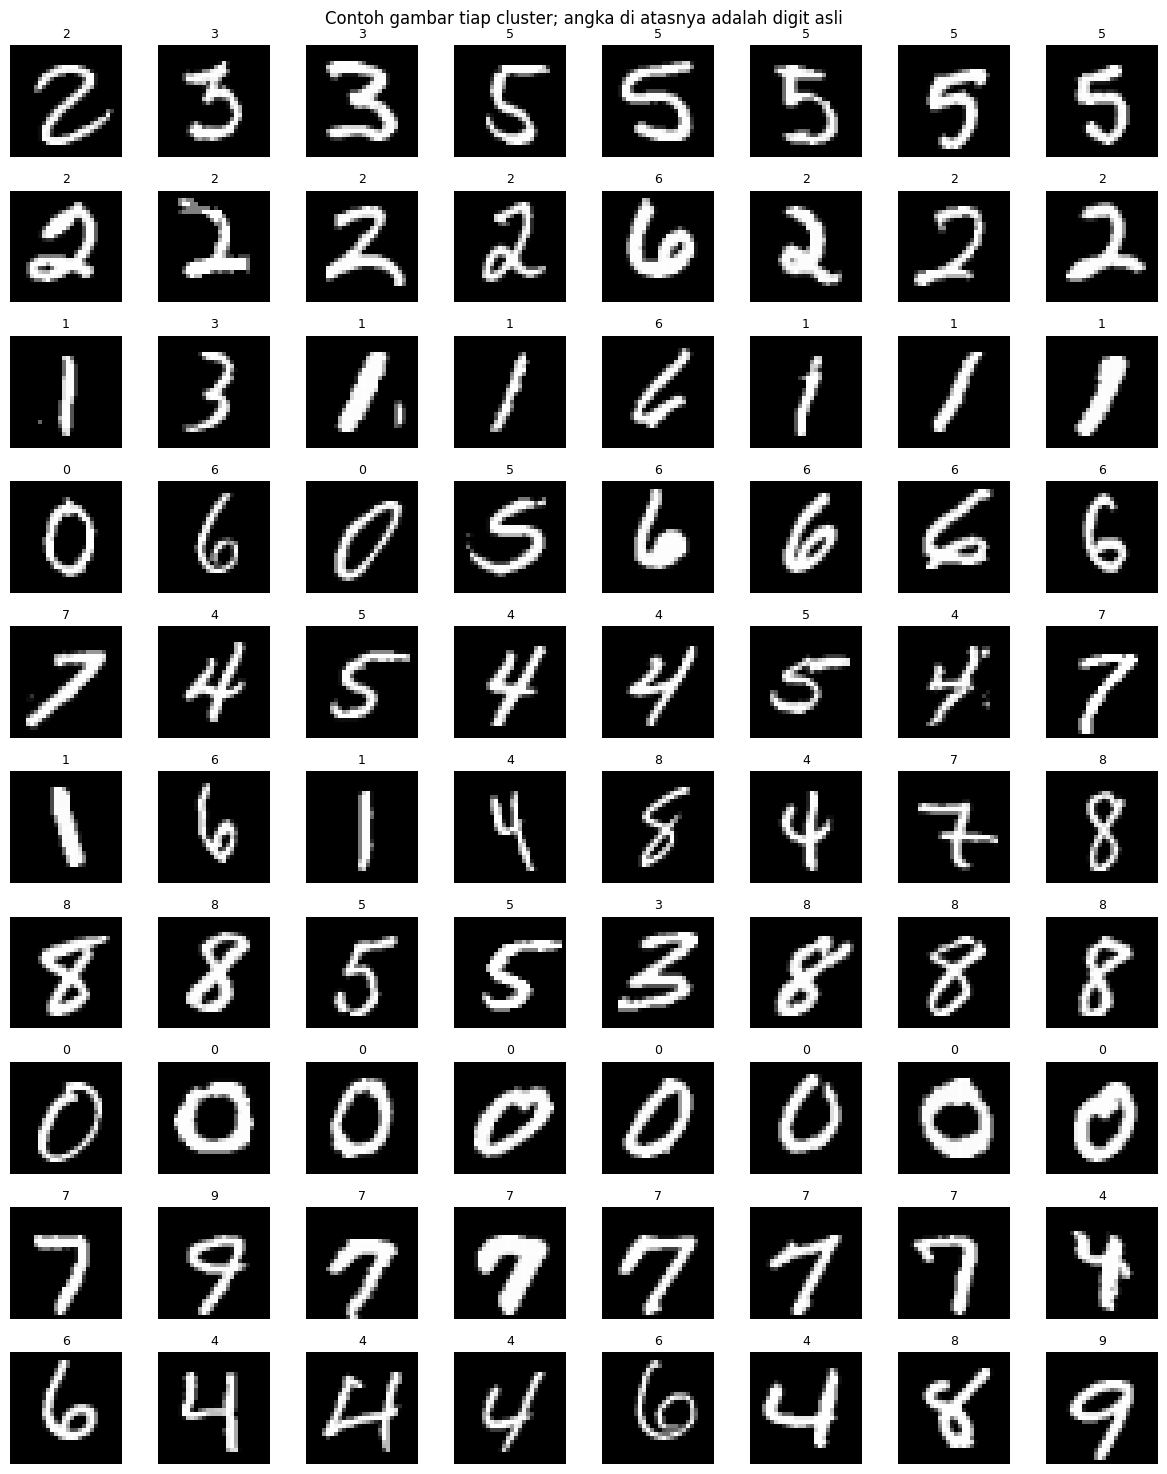

Cluster 0: 1302 gambar; digit dominan 3 (46.5%); digit kedua 5.
Cluster 1: 838 gambar; digit dominan 2 (74.2%); digit kedua 6.
Cluster 2: 1130 gambar; digit dominan 1 (66.7%); digit kedua 2.
Cluster 3: 939 gambar; digit dominan 6 (62.6%); digit kedua 0.
Cluster 4: 1017 gambar; digit dominan 7 (31.0%); digit kedua 4.
Cluster 5: 1130 gambar; digit dominan 1 (32.5%); digit kedua 9.
Cluster 6: 1032 gambar; digit dominan 8 (47.6%); digit kedua 3.
Cluster 7: 784 gambar; digit dominan 0 (92.5%); digit kedua 6.
Cluster 8: 619 gambar; digit dominan 7 (77.5%); digit kedua 9.
Cluster 9: 1209 gambar; digit dominan 4 (47.6%); digit kedua 9.

File hasil_cluster_mnist_uji.csv berhasil dibuat.


In [7]:
fig, axes = plt.subplots(10, 8, figsize=(12, 15))

for cluster in range(10):
    anggota = np.flatnonzero(cluster_uji == cluster)

    contoh = rng.choice(
        anggota,
        size=min(8, len(anggota)),
        replace=False
    )

    for kolom, indeks_gambar in enumerate(contoh):
        axes[cluster, kolom].imshow(
            x_test[indeks_gambar],
            cmap="gray",
            vmin=0,
            vmax=255
        )

        # Angka di atas gambar adalah digit sebenarnya.
        axes[cluster, kolom].set_title(
            str(y_test[indeks_gambar]),
            fontsize=9
        )

    for kolom in range(8):
        axes[cluster, kolom].axis("off")

    axes[cluster, 0].set_ylabel(
        f"C{cluster}",
        rotation=0,
        labelpad=15
    )

plt.suptitle(
    "Contoh gambar tiap cluster; angka di atasnya adalah digit asli"
)
plt.tight_layout()
plt.show()

for _, baris in ringkasan_cluster.iterrows():
    print(
        f"Cluster {int(baris['Cluster'])}: "
        f"{int(baris['Jumlah gambar'])} gambar; "
        f"digit dominan {int(baris['Digit dominan'])} "
        f"({baris['Proporsi dominan']:.1%}); "
        f"digit kedua {int(baris['Digit kedua'])}."
    )

hasil_csv = pd.DataFrame({
    "digit_asli": y_test,
    "cluster": cluster_uji
})

hasil_csv.to_csv(
    "hasil_cluster_mnist_uji.csv",
    index=False
)

print("\nFile hasil_cluster_mnist_uji.csv berhasil dibuat.")

### Interpretasi Sel 6: Representasi Visual Sampel Cluster & Output Akhir
- **Hasil**: Sampel visual mengonfirmasi bahwa cluster terbentuk berdasarkan kemiripan pola goresan (misal bentuk melingkar atau garis tegak).
- **Kesimpulan**: Hasil clustering data uji telah berhasil disimpan ke dalam file `hasil_cluster_mnist_uji.csv` untuk analisis lanjutan.